In [274]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import warnings

import gw_eccentricity as gwe

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")  # silence LAL warnings
from pyseobnr.generate_waveform import GenerateWaveform, generate_modes_opt



# Sampling frequency = 128 Hz from 10 - 20 Hz

In [275]:
# === PARAMETERS ===
m1, m2 = 50.0, 30.0
eccentricity = 0.3
rel_anomaly = np.pi
deltaT = 1.0 / 128.0
f_min = 10.0
f_max = 20.0

params_dict = {
    "mass1": m1, "mass2": m2,
    "spin1x": 0.0, "spin1y": 0.0, "spin1z": 0.0,
    "spin2x": 0.0, "spin2y": 0.0, "spin2z": 0.0,
    "deltaT": deltaT,
    "f22_start": f_min, "f_max": f_max,
    "distance": 1000.0, "inclination": np.pi / 3.0,
    "mode_array": [(2, 2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)],
    "approximant": "SEOBNRv5EHM",
    "eccentricity": eccentricity, "rel_anomaly": rel_anomaly,
    "EccIC": 1, "lmax_nyquist": 1,
}

wfm_gen = GenerateWaveform(params_dict)
times, hlm = wfm_gen.generate_td_modes()

# Find merger time (peak amplitude)
h22_amp = np.abs(hlm[(2, 2)])
merger_idx = np.argmax(h22_amp)
merger_time = times[merger_idx]

print(f"\nMerger at t = {merger_time:.6f} s (index {merger_idx})")

# === TRIM TO INSPIRAL ONLY (EXCLUDE RINGDOWN) ===
trim_cutoff = merger_time - 0.1
trim_mask = times < trim_cutoff
print(f"Trimming to t < {trim_cutoff:.6f} s")

times_trimmed = times[trim_mask]
hlm_trimmed = {key: val[trim_mask] for key, val in hlm.items()}




Merger at t = 0.001553 s (index 351)
Trimming to t < -0.098447 s


/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res = atleast_1d(thefunc(*((x0[:numinputs],) + args)))
/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/pyseobnr/eob/dynamics/integrate_ode_ecc.py:596: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dyn_low_qc, dyn_fine_qc = compute_combined_dynamics(


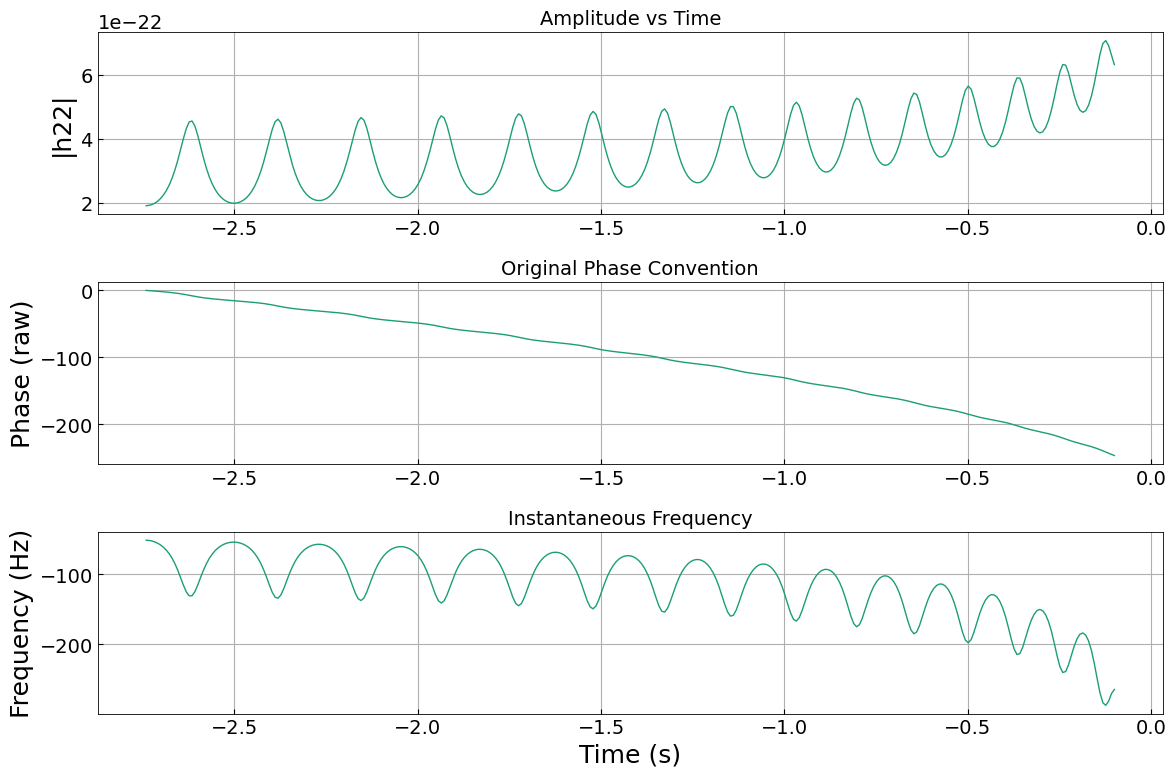

In [276]:
h22 = hlm_trimmed[(2,2)]
times = times_trimmed

def phase(hplus, hcross):
    """
    Calculate the phase from the plus and cross polarizations. Unitless.
    """
    phase = np.unwrap(np.arctan2(hcross, hplus))
    phase -= phase[0] # Normalize phase to start at zero, correcting for the initial phase offset.

    return phase

def plot_freq_and_phase_behavior(h22, times):

    plt.figure(figsize=(12, 8))

    # Top: Amplitude
    plt.subplot(3, 1, 1)
    plt.plot(times, np.abs(h22))
    plt.ylabel('|h22|')
    plt.grid(True)
    plt.title('Amplitude vs Time')

    # Middle: Phase (before fix)
    phi_old = phase(hplus=h22.real, hcross=h22.imag)

    plt.subplot(3, 1, 2)
    plt.plot(times, phi_old)
    plt.ylabel('Phase (raw)')
    plt.grid(True)
    plt.title('Original Phase Convention')

    # Bottom: Frequency
    phi_unwrapped = np.unwrap(phi_old)
    dt = 0.001
    freq_check = np.gradient(phi_unwrapped, dt) / (2*np.pi)

    plt.subplot(3, 1, 3)
    plt.plot(times, freq_check)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.grid(True)
    plt.title('Instantaneous Frequency')

    plt.tight_layout()
    plt.show()

plot_freq_and_phase_behavior(h22, times)

/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/polyrat/arnoldi.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i = int(np.argwhere(diff[j] == -1))
/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/gw_eccentricity/eccDefinition.py:1786: UserWarning: Nonmonotonic time derivative detected in the rational_fit interpolant through pericenters. 
  debug_message(


Saving debug plot to gwecc_Amplitude_diagnostics.pdf


/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/polyrat/arnoldi.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i = int(np.argwhere(diff[j] == -1))


(<Figure size 1200x2800 with 7 Axes>,
 array([<Axes: ylabel='$e_{\\mathrm{gw}}$'>,
        <Axes: ylabel='$l_{\\mathrm{gw}}$ [rad]'>,
        <Axes: ylabel='$\\omega_{\\mathrm{gw}}$ = $\\omega_{22}$'>,
        <Axes: title={'center': 'Data being used for finding the extrema.'}, ylabel='$A_{\\mathrm{gw}}$ = $A_{22}$'>,
        <Axes: ylabel='$de/dt$'>,
        <Axes: title={'center': 'Ratio of phase difference between consecutive extrema'}, ylabel='$\\Delta \\Phi_{orb}[i] / \\Delta \\Phi_{orb}[i-1]$'>,
        <Axes: xlabel='$t$', ylabel='Averaged frequency'>], dtype=object))

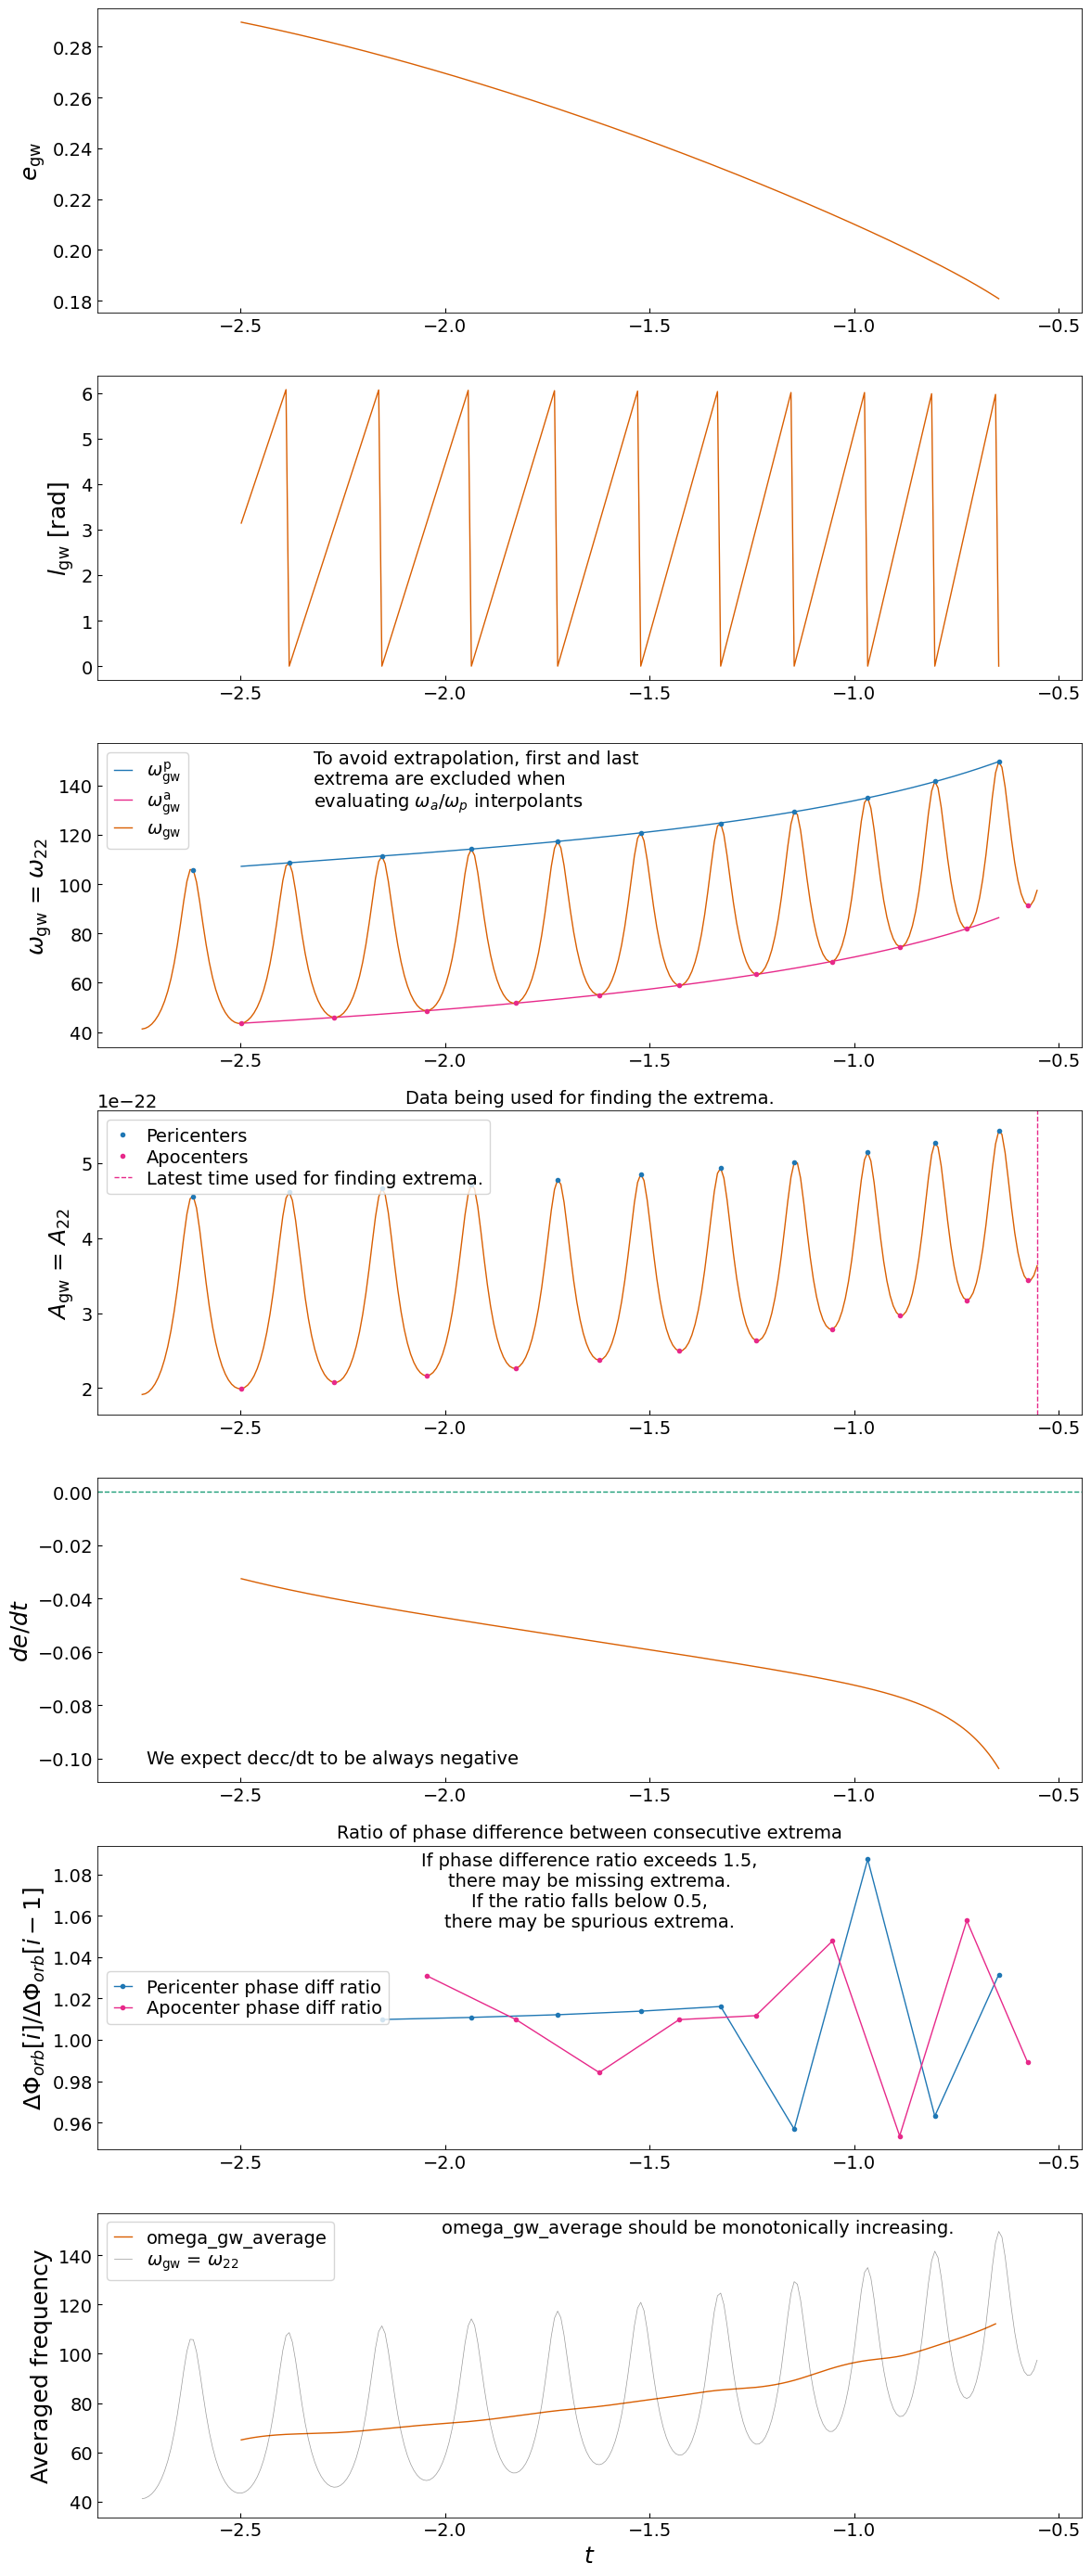

In [277]:
# === MEASURE ECCENTRICITY ===

data_dict_physical = {"t": times_trimmed, "hlm": hlm_trimmed}

return_dict = gwe.measure_eccentricity(
    tref_in=times_trimmed,
    method='Amplitude',        
    dataDict=data_dict_physical,
    num_orbits_to_exclude_before_merger=5,  
    extra_kwargs={
        'debug_plots': True,
    },
)

gwecc_object_128 = return_dict["gwecc_object"]
gwecc_object_128.make_diagnostic_plots()


# Sampling frequency = 2048 Hz, 10-20 Hz

In [278]:
# === PARAMETERS ===
m1, m2 = 50.0, 30.0
eccentricity = 0.3
rel_anomaly = np.pi
deltaT = 1.0 / 2048.0
f_min = 10.0
f_max = 20.0

params_dict = {
    "mass1": m1, "mass2": m2,
    "spin1x": 0.0, "spin1y": 0.0, "spin1z": 0.0,
    "spin2x": 0.0, "spin2y": 0.0, "spin2z": 0.0,
    "deltaT": deltaT,
    "f22_start": f_min, "f_max": f_max,
    "distance": 1000.0, "inclination": np.pi / 3.0,
    "mode_array": [(2, 2), (2, 1), (3, 2), (3, 3), (4, 3), (4, 4)],
    "approximant": "SEOBNRv5EHM",
    "eccentricity": eccentricity, "rel_anomaly": rel_anomaly,
    # "EccIC": 1, "lmax_nyquist": 1,
}

wfm_gen = GenerateWaveform(params_dict)
times, hlm = wfm_gen.generate_td_modes()

# Find merger time (peak amplitude)
h22_amp = np.abs(hlm[(2, 2)])
merger_idx = np.argmax(h22_amp)
merger_time = times[merger_idx]

print(f"\nMerger at t = {merger_time:.6f} s (index {merger_idx})")

# === TRIM TO INSPIRAL ONLY (EXCLUDE RINGDOWN) ===
trim_cutoff = merger_time - 0.1
trim_mask = times < trim_cutoff
print(f"Trimming to t < {trim_cutoff:.6f} s")

times_trimmed = times[trim_mask]
hlm_trimmed = {key: val[trim_mask] for key, val in hlm.items()}




Merger at t = 0.000153 s (index 5616)
Trimming to t < -0.099847 s


/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  res = atleast_1d(thefunc(*((x0[:numinputs],) + args)))
/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/pyseobnr/eob/dynamics/integrate_ode_ecc.py:596: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dyn_low_qc, dyn_fine_qc = compute_combined_dynamics(


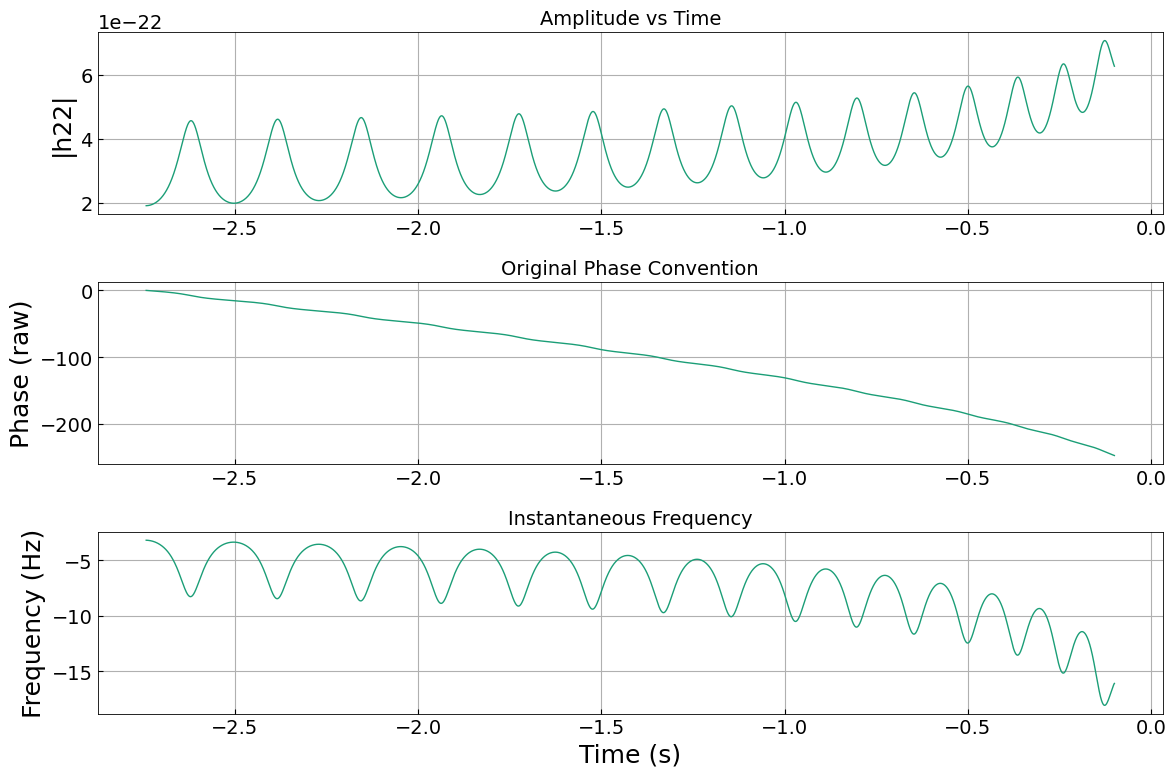

In [279]:
plot_freq_and_phase_behavior(h22=hlm_trimmed[(2,2)], times=times_trimmed)

Saving debug plot to gwecc_Amplitude_diagnostics.pdf


/home/suzanne/anaconda3/envs/phenomxpy/lib/python3.10/site-packages/polyrat/arnoldi.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  i = int(np.argwhere(diff[j] == -1))


(<Figure size 1200x2800 with 7 Axes>,
 array([<Axes: ylabel='$e_{\\mathrm{gw}}$'>,
        <Axes: ylabel='$l_{\\mathrm{gw}}$ [rad]'>,
        <Axes: ylabel='$\\omega_{\\mathrm{gw}}$ = $\\omega_{22}$'>,
        <Axes: title={'center': 'Data being used for finding the extrema.'}, ylabel='$A_{\\mathrm{gw}}$ = $A_{22}$'>,
        <Axes: ylabel='$de/dt$'>,
        <Axes: title={'center': 'Ratio of phase difference between consecutive extrema'}, ylabel='$\\Delta \\Phi_{orb}[i] / \\Delta \\Phi_{orb}[i-1]$'>,
        <Axes: xlabel='$t$', ylabel='Averaged frequency'>], dtype=object))

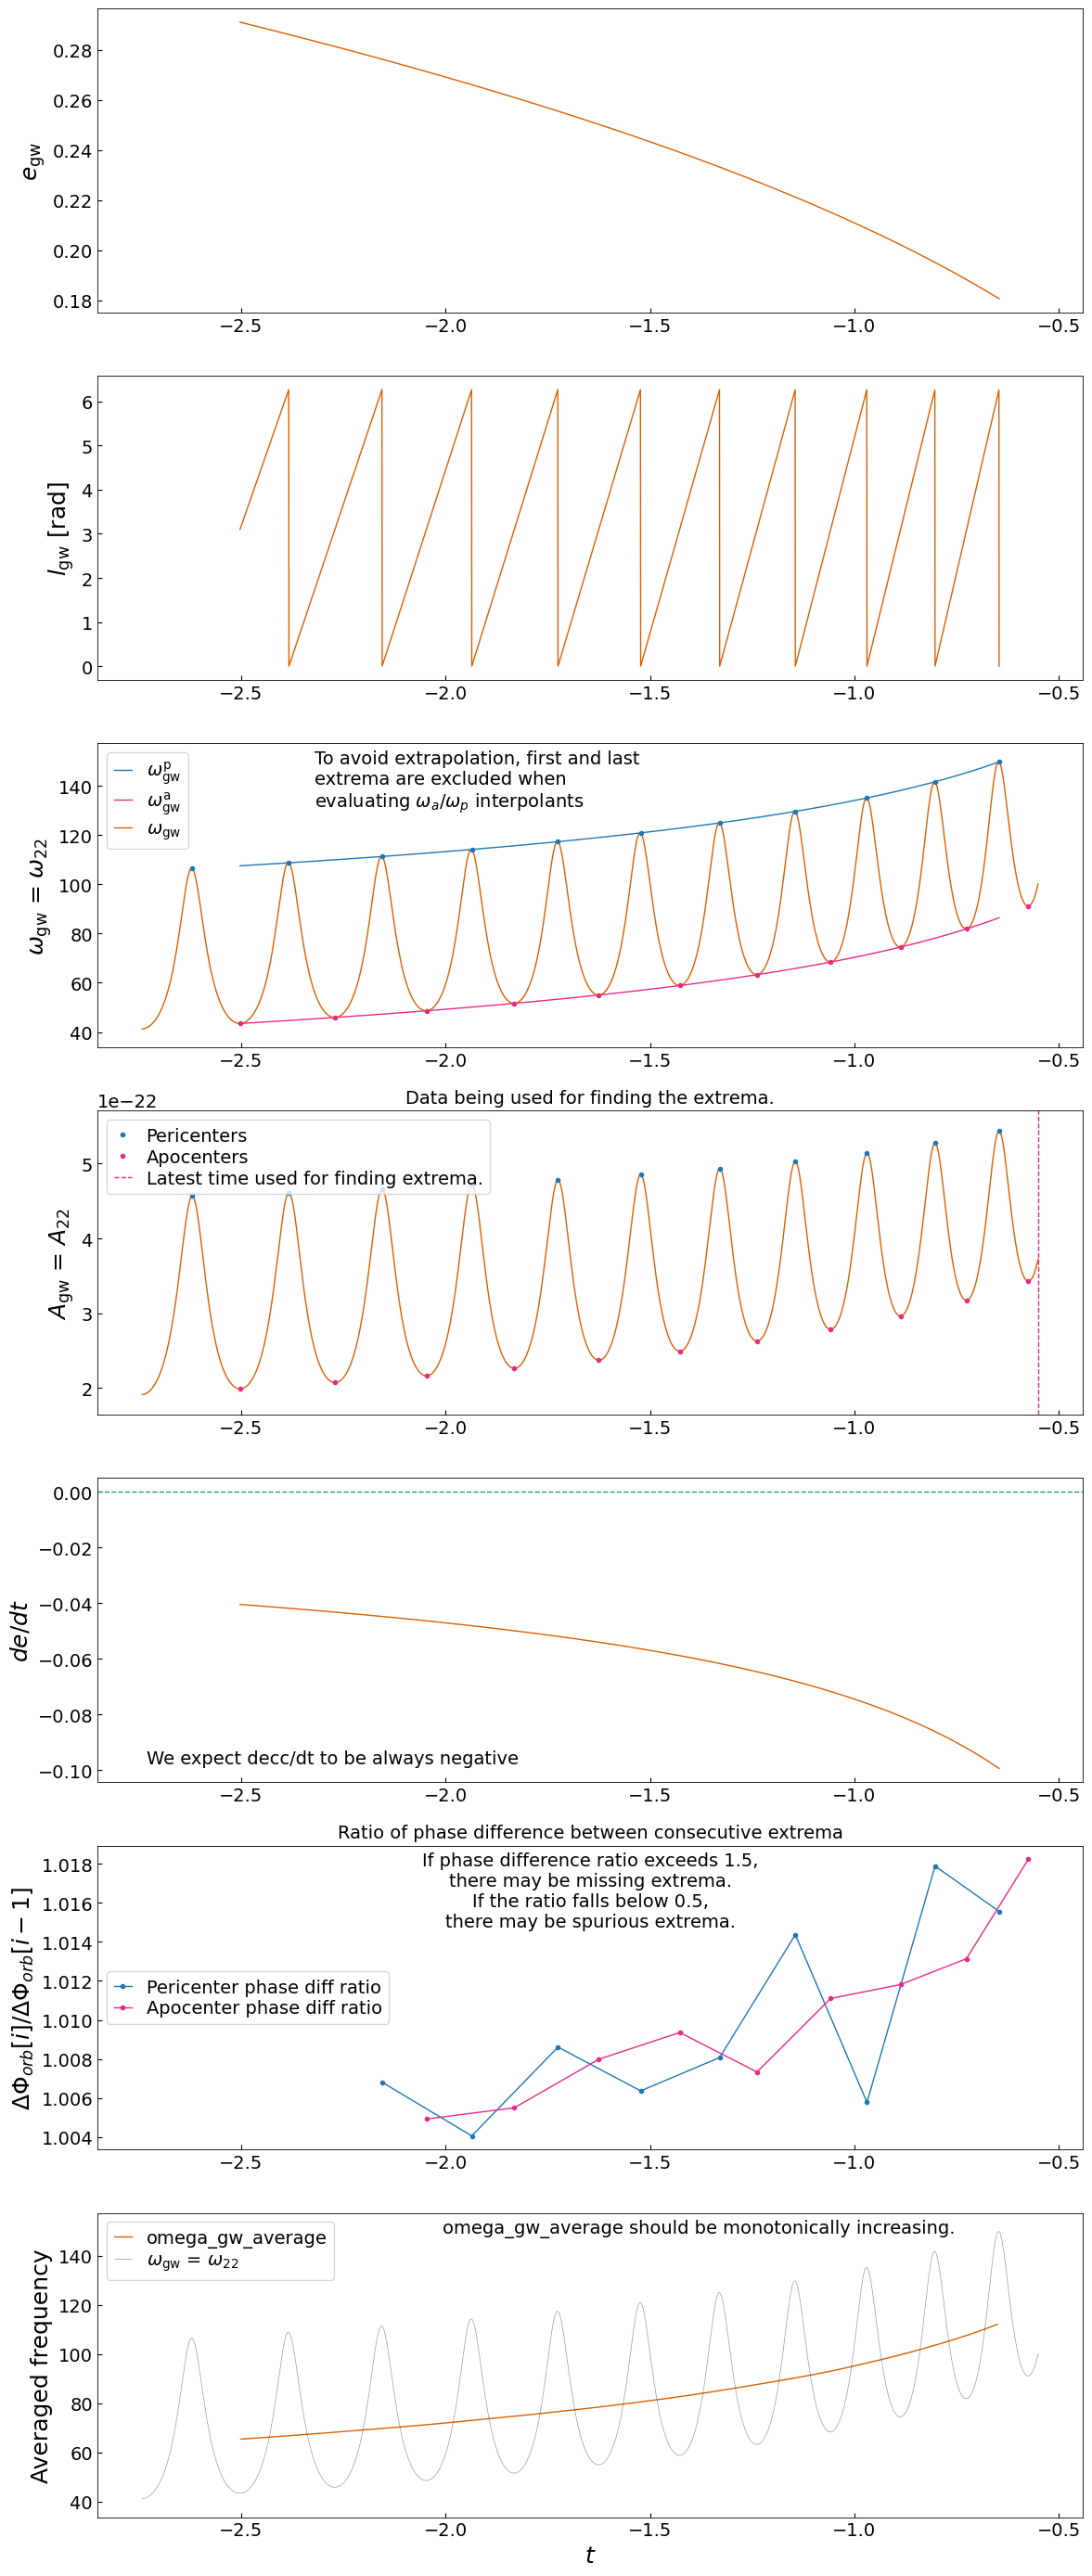

In [280]:
# === MEASURE ECCENTRICITY ===

data_dict_physical = {"t": times_trimmed, "hlm": hlm_trimmed}

return_dict = gwe.measure_eccentricity(
    tref_in=times_trimmed,
    method='Amplitude',        
    dataDict=data_dict_physical,
    num_orbits_to_exclude_before_merger=5,  
    extra_kwargs={
        'debug_plots': True,
    },
)

gwecc_object_2048 = return_dict["gwecc_object"]
gwecc_object_2048.make_diagnostic_plots()


INTERPOLATION AND ACCURACY COMPARISON (OPTION 1)
2048 Hz: 3804 samples, time range: [-2.50, -0.65] s
128 Hz:  238 samples, time range: [-2.50, -0.65] s

ACCURACY METRICS:
Mean absolute difference:    0.000482
Max absolute difference:     0.001323
Relative error (%):          0.16


Saved: eccentricity_comparison_interpolated.png


/tmp/ipykernel_69859/214981357.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


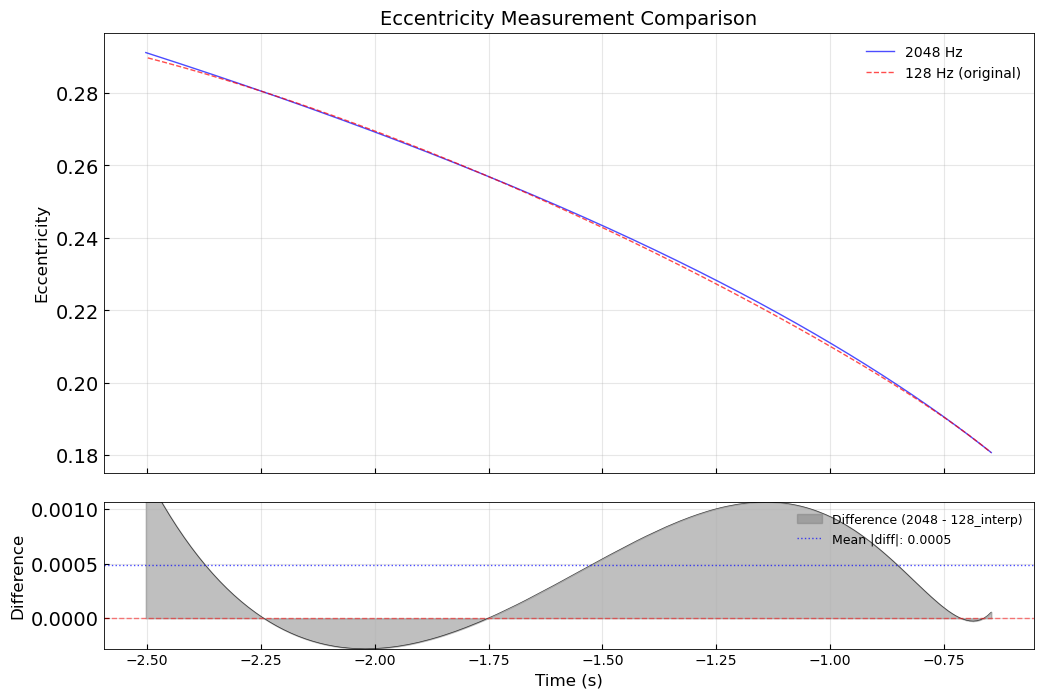

SUMMARY COMPARISON TABLE
| Metric                    | Value                  |
|---------------------------|------------------------|
| Original 2048 Hz points   |       3804           |
| Original 128 Hz points    |        238           |
| Overlap after masking     |       3804           |
| Mean abs. difference      |   0.000482 |
| Median abs. difference    |   0.000348 |
| Max abs. difference       |   0.001323 |
| RMSE                      |   0.000605 |
| Relative error (%)        |       0.16 |
| Std dev of difference     |   0.000468 |


In [281]:
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Your existing results
ecc_2048 = gwecc_object_2048.eccentricity  # Shape: (3804,)
t_2048 = gwecc_object_2048.tref_out         # Time array for 2048 Hz

ecc_128 = gwecc_object_128.eccentricity     # Shape: (238,)
t_128 = gwecc_object_128.tref_out           # Time array for 128 Hz

print("=" * 60)
print("INTERPOLATION AND ACCURACY COMPARISON (OPTION 1)")
print("=" * 60)
print(f"2048 Hz: {len(ecc_2048)} samples, time range: [{t_2048[0]:.2f}, {t_2048[-1]:.2f}] s")
print(f"128 Hz:  {len(ecc_128)} samples, time range: [{t_128[0]:.2f}, {t_128[-1]:.2f}] s")
print()

# ===========================================================================
# INTERPOLATE 128 Hz DATA TO MATCH 2048 Hz GRID 
# ===========================================================================

# Create interpolation function for 128 Hz data
interp_func_128 = interp1d(t_128, ecc_128, kind='linear', 
                           bounds_error=False, fill_value='extrapolate')

# Evaluate on 2048 Hz time grid
ecc_128_interp = interp_func_128(t_2048)

# Calculate point-wise differences
diff = ecc_2048 - ecc_128_interp

print("ACCURACY METRICS:")
print(f"Mean absolute difference:    {np.mean(np.abs(diff)):.6f}")
print(f"Max absolute difference:     {np.max(np.abs(diff)):.6f}")
print(f"Relative error (%):          {np.mean(np.abs(diff))/eccentricity*100:.2f}")
print()

# ===========================================================================
# ERROR VISUALIZATION
# ===========================================================================

fig = plt.figure(figsize=(12, 8))

# Create axes with height ratios
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.1)

# Top subplot: Both eccentricity curves
ax_top = fig.add_subplot(gs[0])
ax_top.plot(t_2048, ecc_2048, 'b-', alpha=0.7, linewidth=1, label='2048 Hz ')
ax_top.plot(t_128, ecc_128, 'r--', alpha=0.7, linewidth=1, label='128 Hz (original)')
ax_top.set_ylabel('Eccentricity', fontsize=12)
ax_top.set_title('Eccentricity Measurement Comparison', fontsize=14)
ax_top.legend(loc='upper right', fontsize=10)
ax_top.grid(True, alpha=0.3)
ax_top.tick_params(axis='x', which='both', labelbottom=False)  # Hide x labels on top

# Bottom subplot: Difference (smaller, height ratio 1/4)
ax_bottom = fig.add_subplot(gs[1])
ax_bottom.fill_between(t_2048, diff, alpha=0.5, color='gray', label='Difference (2048 - 128_interp)')
ax_bottom.plot(t_2048, diff, 'k-', linewidth=0.5, alpha=0.7)
ax_bottom.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax_bottom.axhline(y=np.mean(np.abs(diff)), color='blue', linestyle=':', alpha=0.7, 
                  label=f'Mean |diff|: {np.mean(np.abs(diff)):.4f}')
ax_bottom.axhline(y=-np.mean(np.abs(diff)), color='blue', linestyle=':', alpha=0.7)
ax_bottom.set_xlabel('Time (s)', fontsize=12)
ax_bottom.set_ylabel('Difference', fontsize=12)
ax_bottom.set_ylim([np.percentile(diff, 2), np.percentile(diff, 98)])  # Focus on central range
ax_bottom.legend(loc='upper right', fontsize=9)
ax_bottom.grid(True, alpha=0.3)
ax_bottom.tick_params(axis='x', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('eccentricity_comparison_interpolated.png', dpi=150, bbox_inches='tight')
print("\nSaved: eccentricity_comparison_interpolated.png")
plt.show()

# ===========================================================================
# STATISTICS SUMMARY
# ===========================================================================

print("=" * 60)
print("SUMMARY COMPARISON TABLE")
print("=" * 60)
print(f"| Metric                    | Value                  |")
print(f"|---------------------------|------------------------|")
print(f"| Original 2048 Hz points   | {len(ecc_2048):>10}           |")
print(f"| Original 128 Hz points    | {len(ecc_128):>10}           |")
print(f"| Overlap after masking     | {len(diff):>10}           |")
print(f"| Mean abs. difference      | {np.mean(np.abs(diff)):>10.6f} |")
print(f"| Median abs. difference    | {np.median(np.abs(diff)):>10.6f} |")
print(f"| Max abs. difference       | {np.max(np.abs(diff)):>10.6f} |")
print(f"| RMSE                      | {np.sqrt(np.mean(diff**2)):>10.6f} |")
print(f"| Relative error (%)        | {np.mean(np.abs(diff))/eccentricity*100:>10.2f} |")
print(f"| Std dev of difference     | {np.std(diff):>10.6f} |")
print("=" * 60)